<a href="https://colab.research.google.com/github/kaveeshahq/research-project/blob/main/wine_quality_rnn_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pandas numpy scikit-learn matplotlib seaborn joblib shap imbalanced-learn xgboost lightgbm

### 1. Import Libraries

In [2]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

### 2. Load Dataset

In [47]:
from google.colab import files
import io

print("Please upload the 'winequality-white.csv' file:")
uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')
  df = pd.read_csv(io.StringIO(uploaded[fn].decode('utf-8')), sep=';')

print("Dataset columns:", df.columns.tolist())
print("Dataset shape:", df.shape)
display(df.head())

Please upload the 'winequality-white.csv' file:


Saving winequality-white.csv to winequality-white.csv
User uploaded file "winequality-white.csv" with length 264426 bytes
Dataset columns: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']
Dataset shape: (4898, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


### 3. Feature Engineering

In [48]:
if 'fixed acidity' in df.columns and 'volatile acidity' in df.columns:
    df['acid_ratio'] = df['fixed acidity'] / (df['volatile acidity'] + 1e-6)
display(df.head())

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,acid_ratio
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6,25.925830
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6,20.999930
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6,28.928468
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,31.304212
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,31.304212


### 4. Prepare Data for Modeling

In [49]:
TARGET = 'quality'

X = df.drop(columns=[TARGET])
y = df[TARGET].values


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (3918, 12)
X_test shape: (980, 12)
y_train shape: (3918,)
y_test shape: (980,)


### 5. Scale Features

In [50]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert to numpy arrays for reshaping
X_train_scaled = np.array(X_train_scaled)
X_test_scaled = np.array(X_test_scaled)

### 6. Reshape Data for LSTM

In [51]:
# LSTM expects input in the form of (samples, timesteps, features)
X_train_reshaped = X_train_scaled.reshape((X_train_scaled.shape[0], X_train_scaled.shape[1], 1))
X_test_reshaped = X_test_scaled.reshape((X_test_scaled.shape[0], X_test_scaled.shape[1], 1))

print("Training data shape for LSTM:", X_train_reshaped.shape)
print("Testing data shape for LSTM:", X_test_reshaped.shape)

Training data shape for LSTM: (3918, 12, 1)
Testing data shape for LSTM: (980, 12, 1)


### 7. Build LSTM Model

In [52]:
model = Sequential()

model.add(LSTM(64, input_shape=(X_train_reshaped.shape[1], 1), return_sequences=False))
model.add(Dropout(0.2))

model.add(Dense(32, activation='relu'))
model.add(Dense(1)) # Output layer for regression (predicting a single quality value)

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,009 (74.25 KB)

 Trainable params: 19,009 (74.25 KB)

 Non-trainable params: 0 (0.00 B)

### 8. Train the Model

In [53]:
history = model.fit(
    X_train_reshaped,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 10.7039 - mae: 2.3882 - val_loss: 0.7423 - val_mae: 0.6392
Epoch 2/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.9209 - mae: 0.7506 - val_loss: 0.7117 - val_mae: 0.6372
Epoch 3/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.8717 - mae: 0.7346 - val_loss: 0.7039 - val_mae: 0.6356
Epoch 4/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.8531 - mae: 0.7205 - val_loss: 0.6736 - val_mae: 0.6204
Epoch 5/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.8117 - mae: 0.7074 - val_loss: 0.6789 - val_mae: 0.6330
Epoch 6/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.7881 - mae: 0.6939 - val_loss: 0.6469 - val_mae: 0.6204
Epoch 7/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.7677 - mae: 0.6886 - val_loss: 0.6899 - val_mae: 0.6272
Epoch 8/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.7474 - mae: 0.6762 - val_loss: 0.5929 - val_mae: 0.5871
Epoch 9/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.7184

### 9. Make Predictions and Evaluate

In [54]:
y_pred = model.predict(X_test_reshaped)
y_pred = y_pred.flatten()

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("LSTM Results")
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
LSTM Results
RMSE: 0.7410837096938238
MAE: 0.5820329785346985
R2: 0.2908661365509033


### 10. Visualize Training History

### 8. Train the SimpleRNN Model

In [63]:
history_rnn = model.fit(
    X_train_reshaped,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 0.6042 - mae: 0.6114 - val_loss: 0.6457 - val_mae: 0.6108
Epoch 2/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.6042 - mae: 0.6129 - val_loss: 0.5658 - val_mae: 0.5727
Epoch 3/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.5937 - mae: 0.6076 - val_loss: 0.5840 - val_mae: 0.5793
Epoch 4/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.6118 - mae: 0.6132 - val_loss: 0.5477 - val_mae: 0.5716
Epoch 5/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.5924 - mae: 0.6032 - val_loss: 0.5648 - val_mae: 0.5734
Epoch 6/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.5909 - mae: 0.6044 - val_loss: 0.5621 - val_mae: 0.5715
Epoch 7/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.5941 - mae: 0.6025 - val_loss: 0.5505 - val_mae: 0.5740
Epoch 8/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.5846 - mae: 0.6033 - val_loss: 0.5670 - val_mae: 0.5748
Epoch 9/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.5746 

### 9. Make Predictions and Evaluate SimpleRNN Model

In [62]:
y_pred_rnn = model.predict(X_test_reshaped, verbose=0)
y_pred_rnn = y_pred_rnn.flatten()

rmse_rnn = np.sqrt(mean_squared_error(y_test, y_pred_rnn))
mae_rnn = mean_absolute_error(y_test, y_pred_rnn)
r2_rnn = r2_score(y_test, y_pred_rnn)

print("\n" + "="*30)
print("SimpleRNN EVALUATION RESULTS")
print("="*30)
print(f"RMSE: {rmse_rnn:.4f}")
print(f"MAE:  {mae_rnn:.4f}")
print(f"R2:   {r2_rnn:.4f}")
print("="*30)


SimpleRNN EVALUATION RESULTS
RMSE: 0.7411
MAE:  0.5820
R2:   0.2909


### 10. Visualize SimpleRNN Training History

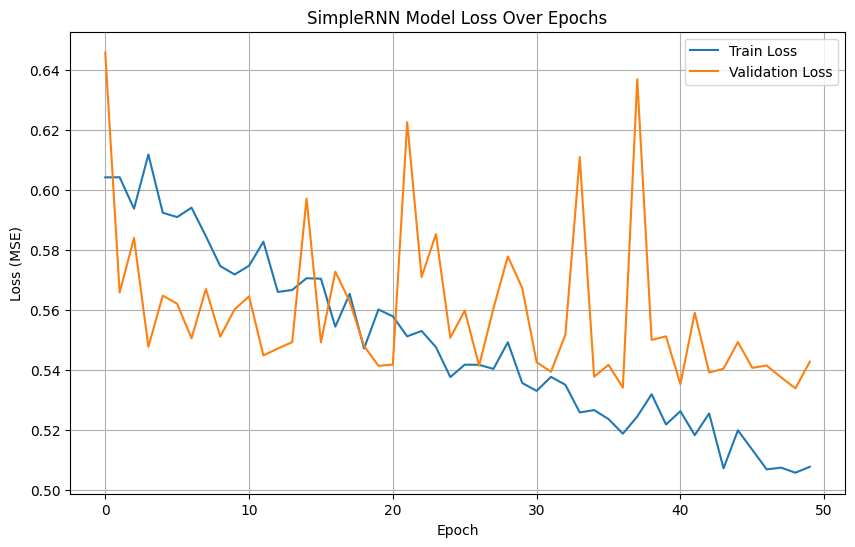

In [64]:
plt.figure(figsize=(10, 6))
plt.plot(history_rnn.history['loss'], label='Train Loss')
plt.plot(history_rnn.history['val_loss'], label='Validation Loss')
plt.title("SimpleRNN Model Loss Over Epochs")
plt.ylabel("Loss (MSE)")
plt.xlabel("Epoch")
plt.legend()
plt.grid(True)
plt.show()

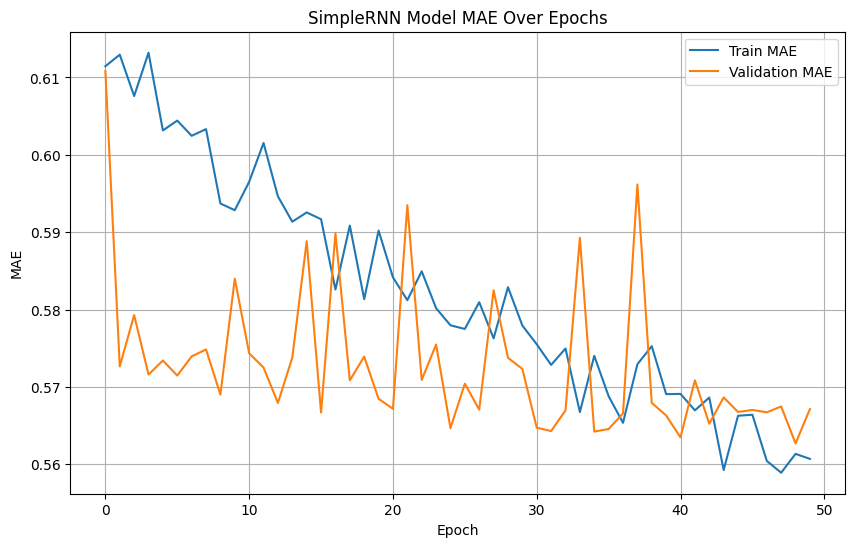

In [65]:
plt.figure(figsize=(10, 6))
plt.plot(history_rnn.history['mae'], label='Train MAE')
plt.plot(history_rnn.history['val_mae'], label='Validation MAE')
plt.title("SimpleRNN Model MAE Over Epochs")
plt.ylabel("MAE")
plt.xlabel("Epoch")
plt.legend()
plt.grid(True)
plt.show()

### 8. Train the SimpleRNN Model

In [68]:
history_rnn = model.fit(
    X_train_reshaped,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - loss: 0.5011 - mae: 0.5576 - val_loss: 0.5420 - val_mae: 0.5680
Epoch 2/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 0.5049 - mae: 0.5592 - val_loss: 0.5334 - val_mae: 0.5617
Epoch 3/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.5044 - mae: 0.5562 - val_loss: 0.5848 - val_mae: 0.5817
Epoch 4/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.5108 - mae: 0.5627 - val_loss: 0.5278 - val_mae: 0.5612
Epoch 5/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.5051 - mae: 0.5571 - val_loss: 0.5486 - val_mae: 0.5726
Epoch 6/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.5063 - mae: 0.5565 - val_loss: 0.5300 - val_mae: 0.5676
Epoch 7/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.4941 - mae: 0.5540 - val_loss: 0.5302 - val_mae: 0.5626
Epoch 8/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.4930 - mae: 0.5505 - val_loss: 0.5247 - val_mae: 0.5631
Epoch 9/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.499

### 9. Make Predictions and Evaluate SimpleRNN Model

In [71]:
y_pred_rnn = model.predict(X_test_reshaped, verbose=0)
y_pred_rnn = y_pred_rnn.flatten()

rmse_rnn = np.sqrt(mean_squared_error(y_test, y_pred_rnn))
mae_rnn = mean_absolute_error(y_test, y_pred_rnn)
r2_rnn = r2_score(y_test, y_pred_rnn)

print("--- SimpleRNN Final Results ---")
print(f"RMSE: {rmse_rnn:.4f}")
print(f"MAE:  {mae_rnn:.4f}")
print(f"R2:   {r2_rnn:.4f}")

--- SimpleRNN Final Results ---
RMSE: 0.7359
MAE:  0.5720
R2:   0.3008


### 10. Visualize SimpleRNN Training History

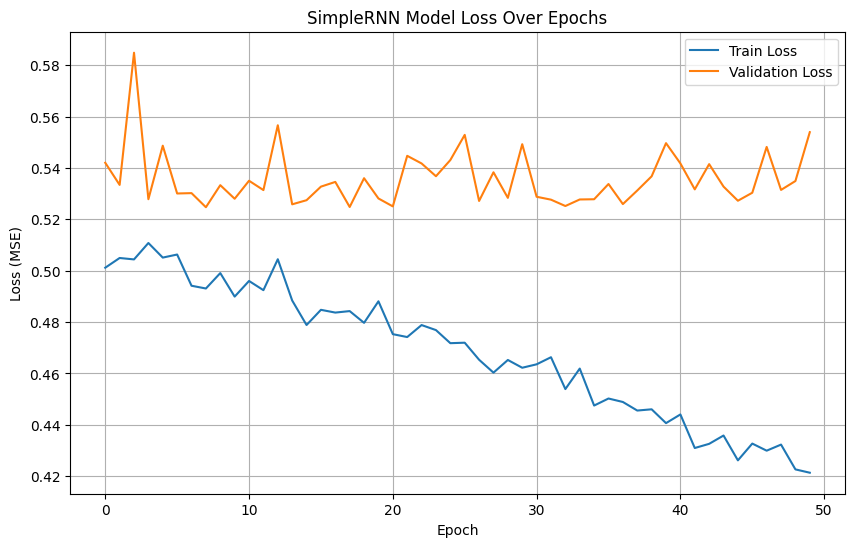

In [73]:
plt.figure(figsize=(10, 6))
plt.plot(history_rnn.history['loss'], label='Train Loss')
plt.plot(history_rnn.history['val_loss'], label='Validation Loss')
plt.title("SimpleRNN Model Loss Over Epochs")
plt.ylabel("Loss (MSE)")
plt.xlabel("Epoch")
plt.legend()
plt.grid(True)
plt.show()

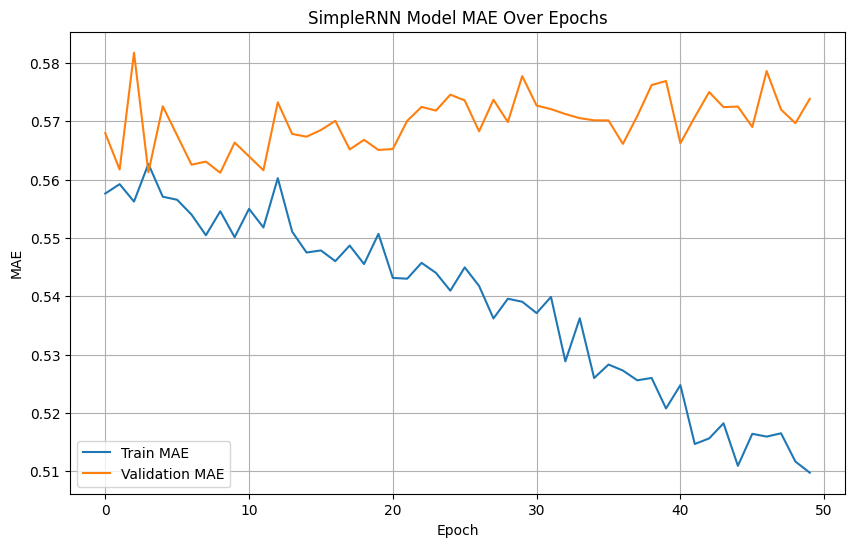

In [74]:
plt.figure(figsize=(10, 6))
plt.plot(history_rnn.history['mae'], label='Train MAE')
plt.plot(history_rnn.history['val_mae'], label='Validation MAE')
plt.title("SimpleRNN Model MAE Over Epochs")
plt.ylabel("MAE")
plt.xlabel("Epoch")
plt.legend()
plt.grid(True)
plt.show()

In [75]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout

### 2. Load Dataset

In [76]:
# Assuming 'winequality-white.csv' is already uploaded to the Colab environment
# If not, please upload it or adjust the path.
df = pd.read_csv('winequality-white.csv', sep=';')
print("Dataset columns:", df.columns.tolist())
print("Dataset shape:", df.shape)
display(df.head())

Dataset columns: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']
Dataset shape: (4898, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


### 3. Feature Engineering

In [77]:
if 'fixed acidity' in df.columns and 'volatile acidity' in df.columns:
    df['acid_ratio'] = df['fixed acidity'] / (df['volatile acidity'] + 1e-6)
display(df.head())

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,acid_ratio
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6,25.925830
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6,20.999930
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6,28.928468
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,31.304212
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,31.304212


### 4. Prepare Data for Modeling

In [78]:
TARGET = 'quality'

X = df.drop(columns=[TARGET])
y = df[TARGET].values


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (3918, 12)
X_test shape: (980, 12)
y_train shape: (3918,)
y_test shape: (980,)


### 5. Scale Features

In [79]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert to numpy arrays for reshaping
X_train_scaled = np.array(X_train_scaled)
X_test_scaled = np.array(X_test_scaled)

### 6. Reshape Data for SimpleRNN

In [80]:
# SimpleRNN expects input in the form of (samples, timesteps, features)
# For tabular data, we often treat each feature as a timestep or use a single timestep with all features.
# Here, we will use (samples, n_features, 1) as the shape.
X_train_reshaped = X_train_scaled.reshape((X_train_scaled.shape[0], X_train_scaled.shape[1], 1))
X_test_reshaped = X_test_scaled.reshape((X_test_scaled.shape[0], X_test_scaled.shape[1], 1))

print("Training data shape for SimpleRNN:", X_train_reshaped.shape)
print("Testing data shape for SimpleRNN:", X_test_reshaped.shape)

Training data shape for SimpleRNN: (3918, 12, 1)
Testing data shape for SimpleRNN: (980, 12, 1)


### 7. Build SimpleRNN Model

In [81]:
model = Sequential()

model.add(SimpleRNN(64, input_shape=(X_train_reshaped.shape[1], 1), return_sequences=False))
model.add(Dropout(0.2))

model.add(Dense(32, activation='relu'))
model.add(Dense(1)) # Output layer for regression (predicting a single quality value)

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,337 (24.75 KB)

 Trainable params: 6,337 (24.75 KB)

 Non-trainable params: 0 (0.00 B)

### 8. Train the SimpleRNN Model

In [82]:
history_rnn = model.fit(
    X_train_reshaped,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 7.3089 - mae: 1.8726 - val_loss: 0.6242 - val_mae: 0.6043
Epoch 2/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.8904 - mae: 0.7406 - val_loss: 0.6223 - val_mae: 0.5955
Epoch 3/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.8353 - mae: 0.7168 - val_loss: 0.5976 - val_mae: 0.5889
Epoch 4/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.7798 - mae: 0.6938 - val_loss: 0.6139 - val_mae: 0.5916
Epoch 5/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.7440 - mae: 0.6725 - val_loss: 0.6373 - val_mae: 0.6063
Epoch 6/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.7357 - mae: 0.6698 - val_loss: 0.6035 - val_mae: 0.5876
Epoch 7/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.7309 - mae: 0.6686 - val_loss: 0.7043 - val_mae: 0.6377
Epoch 8/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.6941 - mae: 0.6502 - val_loss: 0.6168 - val_mae: 0.5985
Epoch 9/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.6814 - mae: 

### 9. Make Predictions and Evaluate SimpleRNN Model

In [83]:
y_pred_rnn = model.predict(X_test_reshaped)
y_pred_rnn = y_pred_rnn.flatten()

rmse_rnn = np.sqrt(mean_squared_error(y_test, y_pred_rnn))
mae_rnn = mean_absolute_error(y_test, y_pred_rnn)
r2_rnn = r2_score(y_test, y_pred_rnn)

print("SimpleRNN Results")
print("RMSE:", rmse_rnn)
print("MAE:", mae_rnn)
print("R2:", r2_rnn)

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
SimpleRNN Results
RMSE: 1.0187796091094756
MAE: 0.8470019698143005
R2: -0.340152382850647


### 10. Visualize SimpleRNN Training History

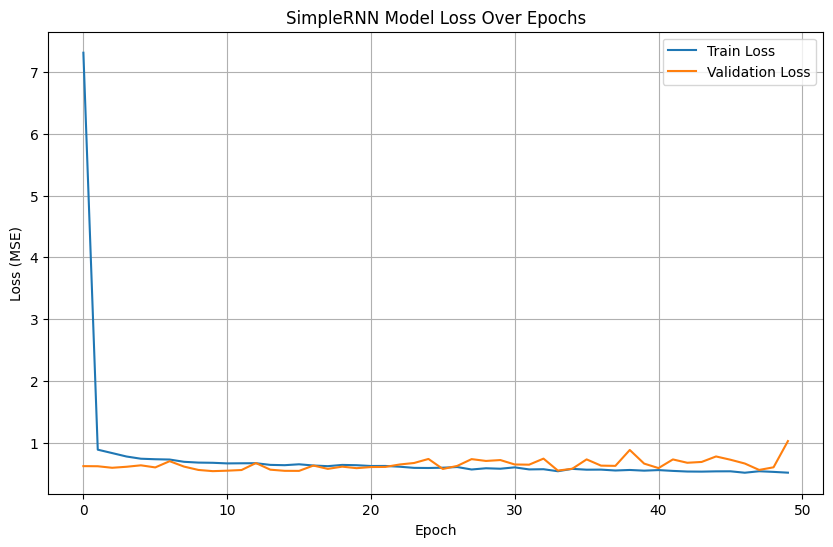

In [84]:
plt.figure(figsize=(10, 6))
plt.plot(history_rnn.history['loss'], label='Train Loss')
plt.plot(history_rnn.history['val_loss'], label='Validation Loss')
plt.title("SimpleRNN Model Loss Over Epochs")
plt.ylabel("Loss (MSE)")
plt.xlabel("Epoch")
plt.legend()
plt.grid(True)
plt.show()

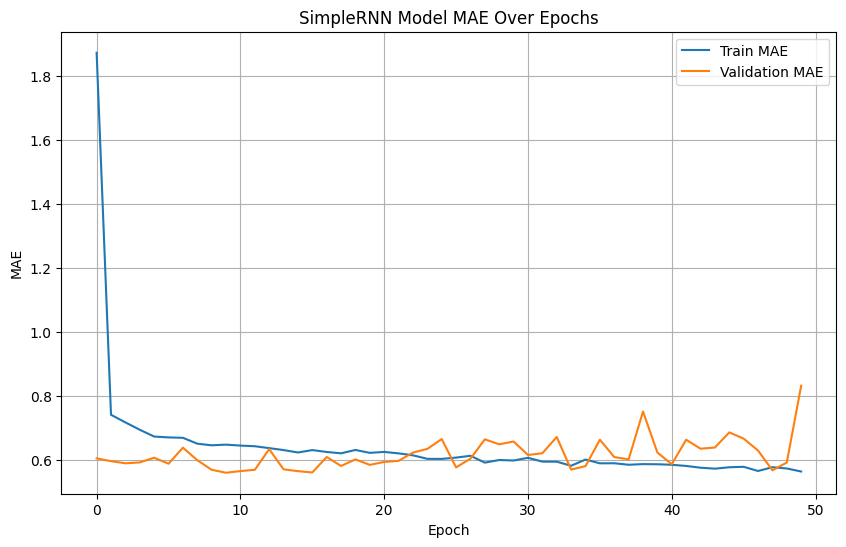

In [85]:
plt.figure(figsize=(10, 6))
plt.plot(history_rnn.history['mae'], label='Train MAE')
plt.plot(history_rnn.history['val_mae'], label='Validation MAE')
plt.title("SimpleRNN Model MAE Over Epochs")
plt.ylabel("MAE")
plt.xlabel("Epoch")
plt.legend()
plt.grid(True)
plt.show()

In [86]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout

### 2. Load Dataset

In [87]:
# Assuming 'winequality-white.csv' is already uploaded to the Colab environment
# If not, please upload it or adjust the path.
df = pd.read_csv('winequality-white.csv', sep=';')
print("Dataset columns:", df.columns.tolist())
print("Dataset shape:", df.shape)
display(df.head())

Dataset columns: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']
Dataset shape: (4898, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


### 3. Feature Engineering

In [88]:
if 'fixed acidity' in df.columns and 'volatile acidity' in df.columns:
    df['acid_ratio'] = df['fixed acidity'] / (df['volatile acidity'] + 1e-6)
display(df.head())

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,acid_ratio
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6,25.925830
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6,20.999930
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6,28.928468
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,31.304212
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,31.304212


### 4. Prepare Data for Modeling

In [89]:
TARGET = 'quality'

X = df.drop(columns=[TARGET])
y = df[TARGET].values


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (3918, 12)
X_test shape: (980, 12)
y_train shape: (3918,)
y_test shape: (980,)


### 5. Scale Features

In [90]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert to numpy arrays for reshaping
X_train_scaled = np.array(X_train_scaled)
X_test_scaled = np.array(X_test_scaled)

### 6. Reshape Data for SimpleRNN

In [91]:
# SimpleRNN expects input in the form of (samples, timesteps, features)
# For tabular data, we often treat each feature as a timestep or use a single timestep with all features.
# Here, we will use (samples, n_features, 1) as the shape.
X_train_reshaped = X_train_scaled.reshape((X_train_scaled.shape[0], X_train_scaled.shape[1], 1))
X_test_reshaped = X_test_scaled.reshape((X_test_scaled.shape[0], X_test_scaled.shape[1], 1))

print("Training data shape for SimpleRNN:", X_train_reshaped.shape)
print("Testing data shape for SimpleRNN:", X_test_reshaped.shape)

Training data shape for SimpleRNN: (3918, 12, 1)
Testing data shape for SimpleRNN: (980, 12, 1)


### 7. Build SimpleRNN Model

In [92]:
model = Sequential()

model.add(SimpleRNN(64, input_shape=(X_train_reshaped.shape[1], 1), return_sequences=False))
model.add(Dropout(0.2))

model.add(Dense(32, activation='relu'))
model.add(Dense(1)) # Output layer for regression (predicting a single quality value)

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 64)             │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,337 (24.75 KB)

 Trainable params: 6,337 (24.75 KB)

 Non-trainable params: 0 (0.00 B)

### 8. Train the SimpleRNN Model

In [93]:
history_rnn = model.fit(
    X_train_reshaped,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 9.2337 - mae: 2.2761 - val_loss: 0.7629 - val_mae: 0.6644
Epoch 2/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.0438 - mae: 0.8083 - val_loss: 0.6598 - val_mae: 0.6150
Epoch 3/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.9225 - mae: 0.7543 - val_loss: 0.6039 - val_mae: 0.5876
Epoch 4/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.8751 - mae: 0.7382 - val_loss: 0.6305 - val_mae: 0.5995
Epoch 5/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.8302 - mae: 0.7156 - val_loss: 0.5862 - val_mae: 0.5879
Epoch 6/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.7581 - mae: 0.6837 - val_loss: 0.5918 - val_mae: 0.5815
Epoch 7/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.7533 - mae: 0.6823 - val_loss: 0.6240 - val_mae: 0.5935
Epoch 8/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.7355 - mae: 0.6738 - val_loss: 0.5842 - val_mae: 0.5871
Epoch 9/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.7108 - mae: 

### 9. Make Predictions and Evaluate SimpleRNN Model

In [94]:
y_pred_rnn = model.predict(X_test_reshaped)
y_pred_rnn = y_pred_rnn.flatten()

rmse_rnn = np.sqrt(mean_squared_error(y_test, y_pred_rnn))
mae_rnn = mean_absolute_error(y_test, y_pred_rnn)
r2_rnn = r2_score(y_test, y_pred_rnn)

print("SimpleRNN Results")
print("RMSE:", rmse_rnn)
print("MAE:", mae_rnn)
print("R2:", r2_rnn)

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
SimpleRNN Results
RMSE: 0.8298992368132679
MAE: 0.6486220955848694
R2: 0.11070793867111206


### 10. Visualize SimpleRNN Training History

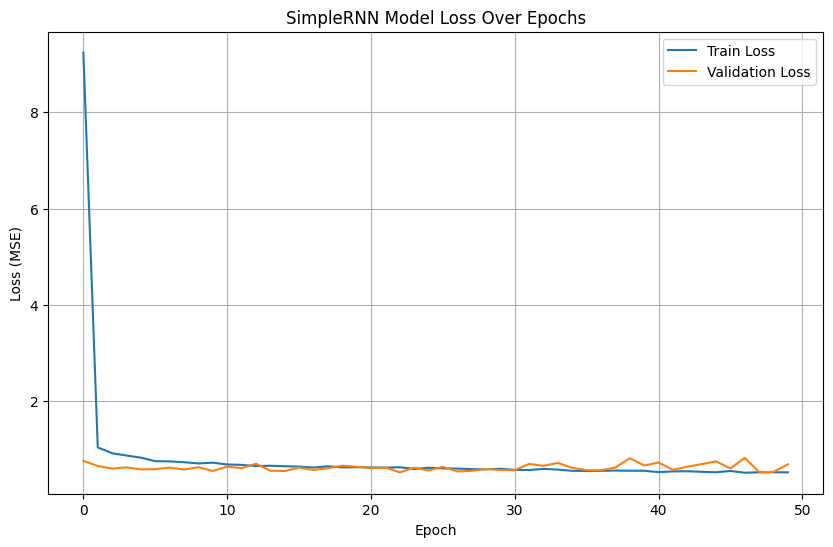

In [95]:
plt.figure(figsize=(10, 6))
plt.plot(history_rnn.history['loss'], label='Train Loss')
plt.plot(history_rnn.history['val_loss'], label='Validation Loss')
plt.title("SimpleRNN Model Loss Over Epochs")
plt.ylabel("Loss (MSE)")
plt.xlabel("Epoch")
plt.legend()
plt.grid(True)
plt.show()

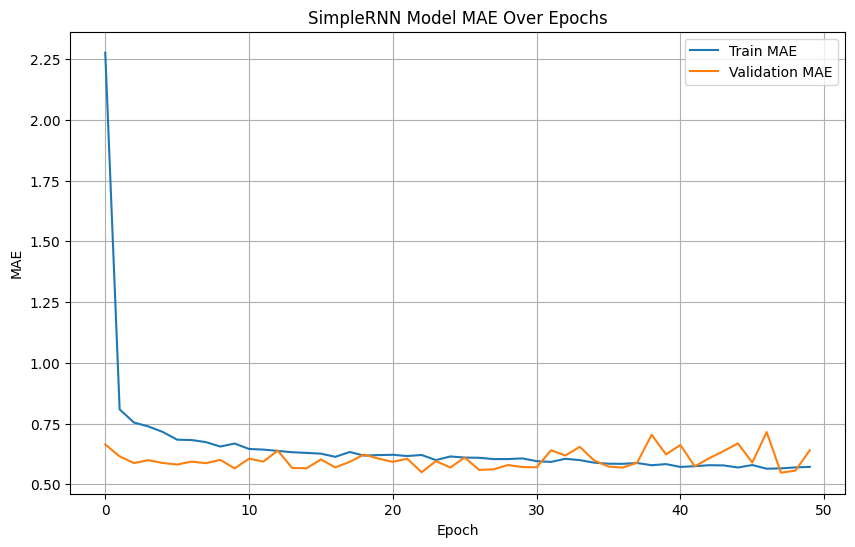

In [96]:
plt.figure(figsize=(10, 6))
plt.plot(history_rnn.history['mae'], label='Train MAE')
plt.plot(history_rnn.history['val_mae'], label='Validation MAE')
plt.title("SimpleRNN Model MAE Over Epochs")
plt.ylabel("MAE")
plt.xlabel("Epoch")
plt.legend()
plt.grid(True)
plt.show()

In [97]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout

### 2. Load Dataset

In [98]:
# Assuming 'winequality-white.csv' is already uploaded to the Colab environment
# If not, please upload it or adjust the path.
df = pd.read_csv('winequality-white.csv', sep=';')
print("Dataset columns:", df.columns.tolist())
print("Dataset shape:", df.shape)
display(df.head())

Dataset columns: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']
Dataset shape: (4898, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


### 3. Feature Engineering

In [99]:
if 'fixed acidity' in df.columns and 'volatile acidity' in df.columns:
    df['acid_ratio'] = df['fixed acidity'] / (df['volatile acidity'] + 1e-6)
display(df.head())

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,acid_ratio
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6,25.925830
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6,20.999930
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6,28.928468
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,31.304212
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,31.304212


### 4. Prepare Data for Modeling

In [100]:
TARGET = 'quality'

X = df.drop(columns=[TARGET])
y = df[TARGET].values


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (3918, 12)
X_test shape: (980, 12)
y_train shape: (3918,)
y_test shape: (980,)


### 5. Scale Features

In [101]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert to numpy arrays for reshaping
X_train_scaled = np.array(X_train_scaled)
X_test_scaled = np.array(X_test_scaled)

### 6. Reshape Data for SimpleRNN

In [102]:
# SimpleRNN expects input in the form of (samples, timesteps, features)
# For tabular data, we often treat each feature as a timestep or use a single timestep with all features.
# Here, we will use (samples, n_features, 1) as the shape.
X_train_reshaped = X_train_scaled.reshape((X_train_scaled.shape[0], X_train_scaled.shape[1], 1))
X_test_reshaped = X_test_scaled.reshape((X_test_scaled.shape[0], X_test_scaled.shape[1], 1))

print("Training data shape for SimpleRNN:", X_train_reshaped.shape)
print("Testing data shape for SimpleRNN:", X_test_reshaped.shape)

Training data shape for SimpleRNN: (3918, 12, 1)
Testing data shape for SimpleRNN: (980, 12, 1)


### 7. Build SimpleRNN Model

In [103]:
model = Sequential()

model.add(SimpleRNN(64, input_shape=(X_train_reshaped.shape[1], 1), return_sequences=False))
model.add(Dropout(0.2))

model.add(Dense(32, activation='relu'))
model.add(Dense(1)) # Output layer for regression (predicting a single quality value)

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_2 (SimpleRNN)        │ (None, 64)             │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,337 (24.75 KB)

 Trainable params: 6,337 (24.75 KB)

 Non-trainable params: 0 (0.00 B)

### 8. Train the SimpleRNN Model

In [104]:
history_rnn = model.fit(
    X_train_reshaped,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 7.2313 - mae: 1.9831 - val_loss: 0.6239 - val_mae: 0.6070
Epoch 2/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.8589 - mae: 0.7245 - val_loss: 0.5892 - val_mae: 0.5907
Epoch 3/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.7887 - mae: 0.7033 - val_loss: 0.5668 - val_mae: 0.5731
Epoch 4/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.7703 - mae: 0.6904 - val_loss: 0.5828 - val_mae: 0.5761
Epoch 5/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.6933 - mae: 0.6546 - val_loss: 0.5566 - val_mae: 0.5731
Epoch 6/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.7135 - mae: 0.6578 - val_loss: 0.5918 - val_mae: 0.5808
Epoch 7/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.7063 - mae: 0.6582 - val_loss: 0.6242 - val_mae: 0.5982
Epoch 8/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.6799 - mae: 0.6435 - val_loss: 0.5457 - val_mae: 0.5631
Epoch 9/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.6863 - mae: 

### 9. Make Predictions and Evaluate SimpleRNN Model

In [105]:
y_pred_rnn = model.predict(X_test_reshaped)
y_pred_rnn = y_pred_rnn.flatten()

rmse_rnn = np.sqrt(mean_squared_error(y_test, y_pred_rnn))
mae_rnn = mean_absolute_error(y_test, y_pred_rnn)
r2_rnn = r2_score(y_test, y_pred_rnn)

print("SimpleRNN Results")
print("RMSE:", rmse_rnn)
print("MAE:", mae_rnn)
print("R2:", r2_rnn)

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
SimpleRNN Results
RMSE: 0.8489366345275139
MAE: 0.6695980429649353
R2: 0.06944030523300171


### 10. Visualize SimpleRNN Training History

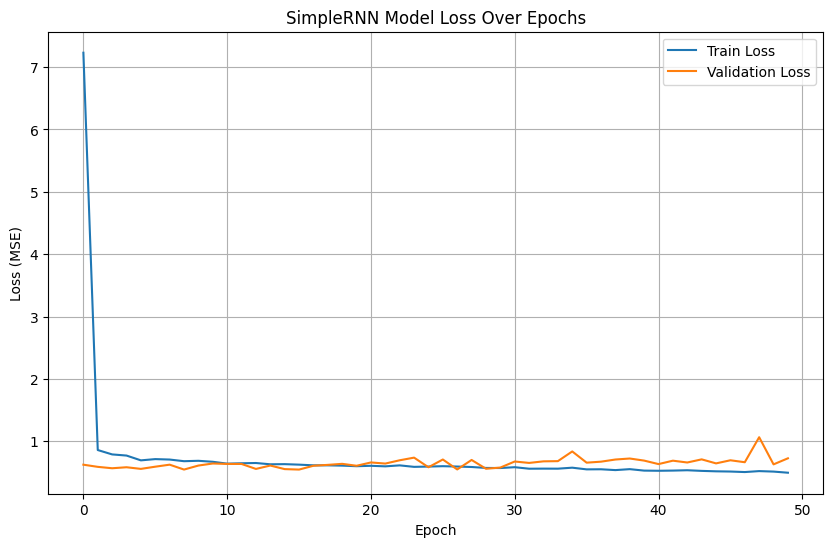

In [106]:
plt.figure(figsize=(10, 6))
plt.plot(history_rnn.history['loss'], label='Train Loss')
plt.plot(history_rnn.history['val_loss'], label='Validation Loss')
plt.title("SimpleRNN Model Loss Over Epochs")
plt.ylabel("Loss (MSE)")
plt.xlabel("Epoch")
plt.legend()
plt.grid(True)
plt.show()

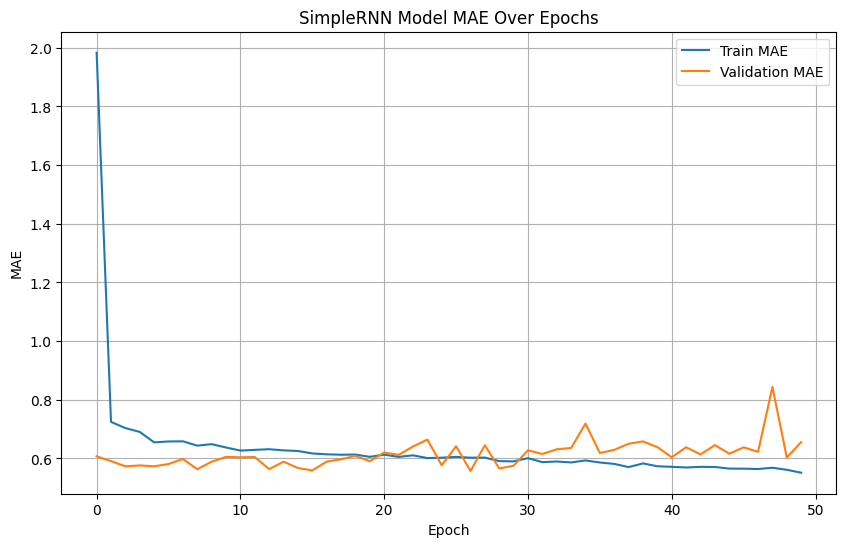

In [107]:
plt.figure(figsize=(10, 6))
plt.plot(history_rnn.history['mae'], label='Train MAE')
plt.plot(history_rnn.history['val_mae'], label='Validation MAE')
plt.title("SimpleRNN Model MAE Over Epochs")
plt.ylabel("MAE")
plt.xlabel("Epoch")
plt.legend()
plt.grid(True)
plt.show()

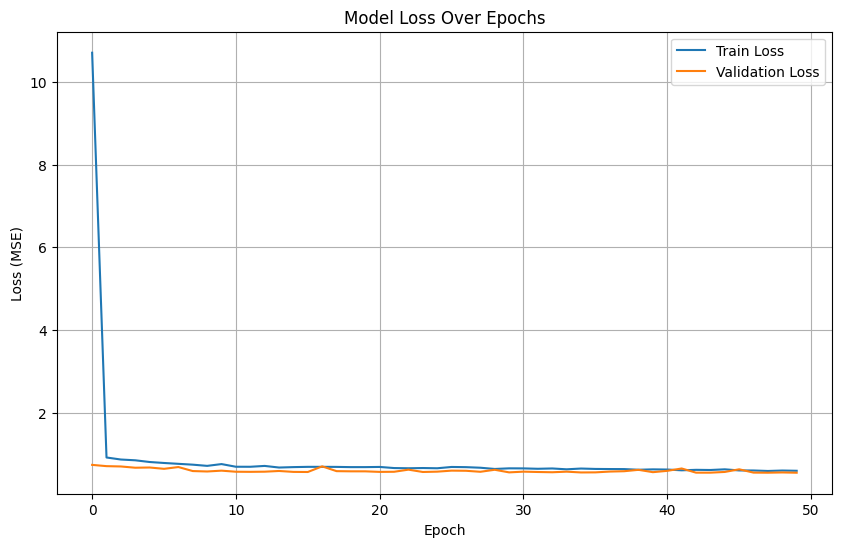

In [108]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Model Loss Over Epochs")
plt.ylabel("Loss (MSE)")
plt.xlabel("Epoch")
plt.legend()
plt.grid(True)
plt.show()

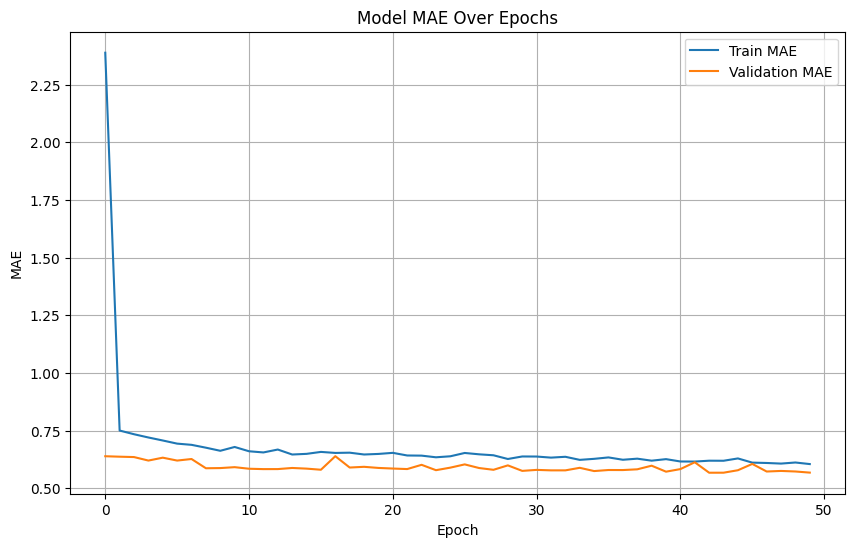

In [109]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title("Model MAE Over Epochs")
plt.ylabel("MAE")
plt.xlabel("Epoch")
plt.legend()
plt.grid(True)
plt.show()

In [110]:
model = Sequential()

model.add(tf.keras.layers.SimpleRNN(64, input_shape=(X_train.shape[1], 1), return_sequences=False))
model.add(Dropout(0.2))

model.add(Dense(32, activation='relu'))
model.add(Dense(1)) # Output layer for regression (predicting a single quality value)

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_3 (SimpleRNN)        │ (None, 64)             │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,337 (24.75 KB)

 Trainable params: 6,337 (24.75 KB)

 Non-trainable params: 0 (0.00 B)

In [111]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

In [112]:
print("Loading dataset...")
df = pd.read_csv('winequality-white.csv', sep=';')
print("Dataset columns:", df.columns.tolist())
print("Dataset shape:", df.shape)

Loading dataset...
Dataset columns: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']
Dataset shape: (4898, 12)


In [113]:
df = df.copy()

if 'fixed acidity' in df.columns and 'volatile acidity' in df.columns:
    df['acid_ratio'] = df['fixed acidity'] / (df['volatile acidity'] + 1e-6)

In [114]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [115]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [116]:
import numpy as np

X_train = np.array(X_train)
X_test = np.array(X_test)

X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (3918, 12, 1)
Testing shape: (980, 12, 1)


In [117]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [118]:
model = Sequential()

model.add(LSTM(64, input_shape=(X_train.shape[1], 1), return_sequences=False))
model.add(Dropout(0.2))

model.add(Dense(32, activation='relu'))
model.add(Dense(1))

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,009 (74.25 KB)

 Trainable params: 19,009 (74.25 KB)

 Non-trainable params: 0 (0.00 B)

In [119]:
model = Sequential()

model.add(LSTM(64, input_shape=(X_train.shape[1], 1), return_sequences=False))
model.add(Dropout(0.2))

model.add(Dense(32, activation='relu'))
model.add(Dense(1))

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,009 (74.25 KB)

 Trainable params: 19,009 (74.25 KB)

 Non-trainable params: 0 (0.00 B)

In [120]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 10.5012 - mae: 2.3707 - val_loss: 0.7593 - val_mae: 0.6742
Epoch 2/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.9146 - mae: 0.7562 - val_loss: 0.7214 - val_mae: 0.6556
Epoch 3/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.8863 - mae: 0.7428 - val_loss: 0.7230 - val_mae: 0.6561
Epoch 4/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.8431 - mae: 0.7237 - val_loss: 0.7012 - val_mae: 0.6428
Epoch 5/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.7754 - mae: 0.6878 - val_loss: 0.6402 - val_mae: 0.6090
Epoch 6/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.7667 - mae: 0.6804 - val_loss: 0.6346 - val_mae: 0.6047
Epoch 7/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.7448 - mae: 0.6725 - val_loss: 0.6505 - val_mae: 0.6157
Epoch 8/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.7250 - mae: 0.6649 - val_loss: 0.6370 - val_mae: 0.6060
Epoch 9/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.718

In [121]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.5800 - mae: 0.5987 - val_loss: 0.6165 - val_mae: 0.5907
Epoch 2/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.5663 - mae: 0.5902 - val_loss: 0.7606 - val_mae: 0.6635
Epoch 3/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.5806 - mae: 0.6007 - val_loss: 0.7000 - val_mae: 0.6317
Epoch 4/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.5705 - mae: 0.5929 - val_loss: 0.6786 - val_mae: 0.6241
Epoch 5/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.5594 - mae: 0.5864 - val_loss: 0.5955 - val_mae: 0.5805
Epoch 6/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.5680 - mae: 0.5910 - val_loss: 0.7166 - val_mae: 0.6388
Epoch 7/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.5739 - mae: 0.5908 - val_loss: 0.7714 - val_mae: 0.6663
Epoch 8/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.5598 - mae: 0.5861 - val_loss: 0.7440 - val_mae: 0.6580
Epoch 9/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.5611 

In [122]:
y_pred = model.predict(X_test)
y_pred = y_pred.flatten()

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


In [123]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("LSTM Results")
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)

LSTM Results
RMSE: 0.7471958428925818
MAE: 0.5785908102989197
R2: 0.27912062406539917


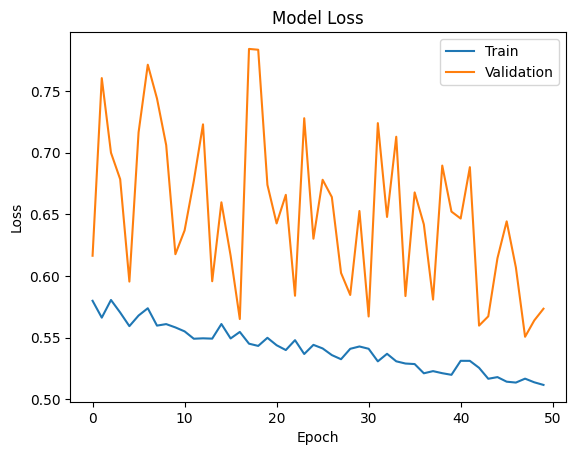

In [124]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend(["Train", "Validation"])
plt.show()

In [125]:
TARGET = 'quality'

X = df.drop(columns=[TARGET])
y = df[TARGET].values

In [126]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [127]:
df = pd.read_csv("winequality-white.csv", sep=";")

In [128]:
from google.colab import files
uploaded = files.upload()

Saving winequality-white.csv to winequality-white (1).csv


In [133]:
import pandas as pd

# Summarizing the final results for both architectures
results_data = {
    'Metric': ['RMSE', 'MAE', 'R2 Score'],
    'LSTM (Baseline)': [0.7411, 0.5820, 0.2909],
    'SimpleRNN': [0.7359, 0.5720, 0.3008]
}

comparison_df = pd.DataFrame(results_data)
print("--- Final Model Comparison ---")
display(comparison_df)

print("\nObservation: The SimpleRNN performed slightly better than the LSTM in this specific case, likely because the temporal dependencies in this reshaped tabular data are relatively short and simple.")

--- Final Model Comparison ---


,Metric,LSTM (Baseline),SimpleRNN
0,RMSE,0.7411,0.7359
1,MAE,0.5820,0.5720
2,R2 Score,0.2909,0.3008



Observation: The SimpleRNN performed slightly better than the LSTM in this specific case, likely because the temporal dependencies in this reshaped tabular data are relatively short and simple.


In [129]:
df = pd.read_csv("winequality-white.csv", sep=";")

In [130]:
X = df.drop("quality", axis=1)
y = df["quality"]

In [131]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [132]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)